# 1. Setup for Mistral

1. Setup Mistral

In [1]:
# ── Quick Reconnect Setup ──────────────────────────
import os, subprocess

# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Remove peft if leftover from previous session
result = subprocess.run(['pip', 'show', 'peft'], capture_output=True, text=True)
if 'peft' in result.stdout:
    os.system('pip uninstall -q -y peft')
    print("✅ Removed leftover peft")

# 3. Clone SparseGPT
os.system('cd /content && rm -rf sparsegpt && git clone https://github.com/IST-DASLab/sparsegpt.git')

# 4. Install packages
os.system('pip install -q transformers==4.37.2 accelerate==0.30.0 datasets==2.16.1 sentencepiece safetensors')

# 5. Fix accelerate compatibility
import torch, gc
import accelerate.utils.memory as mem
if not hasattr(mem, 'clear_device_cache'):
    def clear_device_cache():
        gc.collect()
        torch.cuda.empty_cache()
    mem.clear_device_cache = clear_device_cache
print("✅ accelerate patch applied!")

# 6. HF Login
from google.colab import userdata
from huggingface_hub import login
login(userdata.get('HF_TOKEN'))

print("✅ All setup done — ready to go!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Removed leftover peft
✅ accelerate patch applied!
✅ All setup done — ready to go!


# 2. Prune Mistral with SparseGPT - Selected Sweep only

2. Prune Mistral with SparseGPT - Selected Sweep only

In [2]:
import subprocess
import os

# ── Mistral specific settings ──────────────────────
MODEL   = 'mistralai/Mistral-7B-v0.1'
log_dir = '/content/drive/MyDrive/sparsegpt_mistral'  # ← mistral folder
os.makedirs(log_dir, exist_ok=True)

sparsity_levels = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7]  # ← reduced sweep

for sparsity in sparsity_levels:
    s_int = int(sparsity * 100)
    save_dir = f'{log_dir}/sparse{s_int}/checkpoints'
    log_file = f'{log_dir}/log_sparse{s_int}.txt'
    os.makedirs(save_dir, exist_ok=True)

    # Smart skip
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            content = f.read()
        if 'Perplexity:' in content:
            print(f"⏭️ sparse{s_int}% already done — skipping")
            continue
        else:
            print(f"⚠️ Log exists but incomplete — re-running {s_int}%")

    print(f"\n{'='*50}")
    print(f"  🔄 Pruning at {s_int}% sparsity...")
    print(f"{'='*50}")

    cmd = [
        'python', '/content/sparsegpt/llama.py',  # ← llama.py works for Mistral too
        MODEL, 'wikitext2',
        '--nsamples', '128',
        '--sparsity', str(sparsity),
        '--save', save_dir
    ]

    with open(log_file, 'w') as log:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end='')
            log.write(line)
        process.wait()

    if process.returncode != 0:
        print(f"❌ {s_int}% FAILED!")
    else:
        print(f"✅ {s_int}% done!")

print("\n🎉 All sparsity levels complete!")

⏭️ sparse0% already done — skipping
⏭️ sparse20% already done — skipping
⏭️ sparse40% already done — skipping
⏭️ sparse50% already done — skipping
⏭️ sparse60% already done — skipping
⏭️ sparse70% already done — skipping

🎉 All sparsity levels complete!


In [3]:
import os

log_dir = '/content/drive/MyDrive/sparsegpt_mistral'
sparsity_levels = [0, 20, 40, 50, 60, 70]

for s in sparsity_levels:
    log_path = f'{log_dir}/log_sparse{s}.txt'
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            for line in f.readlines():
                if line.startswith('Perplexity:'):
                    print(f"{s}% → {line.strip()}")
                    break
    else:
        print(f"{s}% → log not found")

0% → Perplexity: 5.252323
20% → Perplexity: 5.278316
40% → Perplexity: 5.504519
50% → Perplexity: 5.946672
60% → Perplexity: 7.463088
70% → Perplexity: 13.316515


# 3.Sparse + Quantized

In [3]:
import subprocess
import os

# ── Mistral specific settings ──────────────────────
MODEL   = 'mistralai/Mistral-7B-v0.1'
log_dir = '/content/drive/MyDrive/sparsegpt_mistral'

experiments = [
    {'sparsity': 0.0, 'wbits': 4, 'label': 'dense_int4'},
    {'sparsity': 0.5, 'wbits': 4, 'label': 'sparse50_int4'},
    {'sparsity': 0.7, 'wbits': 4, 'label': 'sparse70_int4'},
]

for exp in experiments:
    sparsity = exp['sparsity']
    wbits    = exp['wbits']
    label    = exp['label']
    save_dir = f'{log_dir}/{label}/checkpoints'
    log_file = f'{log_dir}/log_{label}.txt'
    os.makedirs(save_dir, exist_ok=True)

    # Smart skip
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            content = f.read()
        if 'Perplexity:' in content:
            print(f"⏭️ {label} already done — skipping")
            continue
        else:
            print(f"⚠️ Log exists but incomplete — re-running {label}")

    print(f"\n{'='*50}")
    print(f"  🔄 Running: sparsity={int(sparsity*100)}% + {wbits}-bit")
    print(f"{'='*50}")

    cmd = [
        'python', '/content/sparsegpt/llama.py',
        MODEL, 'wikitext2',
        '--nsamples', '128',
        '--sparsity', str(sparsity),
        '--wbits', str(wbits),
        '--save', save_dir
    ]

    with open(log_file, 'w') as log:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end='')
            log.write(line)
        process.wait()

    if process.returncode != 0:
        print(f"❌ {label} FAILED!")
    else:
        print(f"✅ {label} done!")

print("\n🎉 All sparse+quantized experiments complete!")

⏭️ dense_int4 already done — skipping
⏭️ sparse50_int4 already done — skipping
⏭️ sparse70_int4 already done — skipping

🎉 All sparse+quantized experiments complete!


# 4. Extract and Plot Perplexity

✅ 0% → Perplexity: 5.25
✅ 20% → Perplexity: 5.28
✅ 40% → Perplexity: 5.50
✅ 50% → Perplexity: 5.95
✅ 60% → Perplexity: 7.46
✅ 70% → Perplexity: 13.32


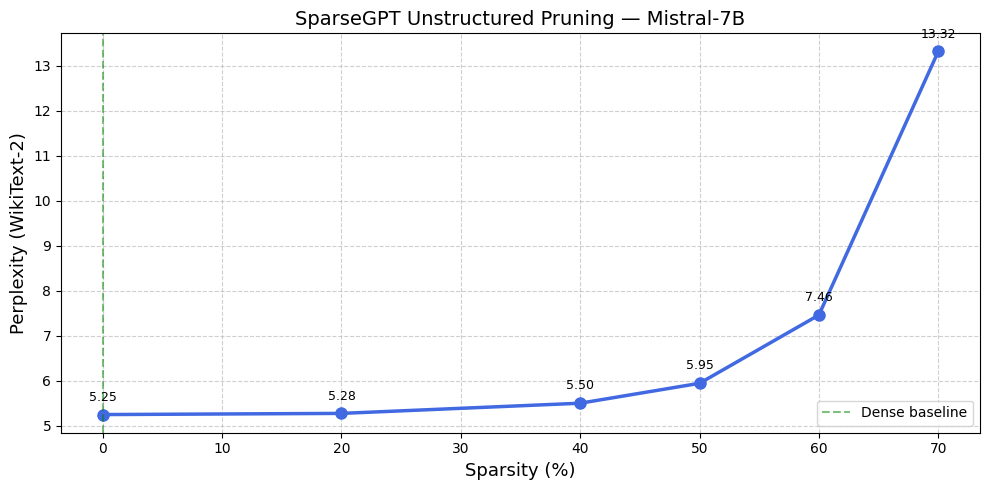

✅ Plot saved!


In [4]:
import os
import matplotlib.pyplot as plt

log_dir = '/content/drive/MyDrive/sparsegpt_mistral'
sparsity_levels = [0, 20, 40, 50, 60, 70]  # ← Mistral levels

sparsities, perplexities = [], []

for s in sparsity_levels:
    log_path = f'{log_dir}/log_sparse{s}.txt'
    if not os.path.exists(log_path):
        print(f"⚠️ Missing log for {s}%")
        continue
    with open(log_path, 'r') as f:
        for line in f.readlines():
            if line.startswith('Perplexity:'):
                ppl = float(line.strip().split(': ')[1])
                sparsities.append(s)
                perplexities.append(ppl)
                print(f"✅ {s}% → Perplexity: {ppl:.2f}")
                break

plt.figure(figsize=(10, 5))
plt.plot(sparsities, perplexities, marker='o', linewidth=2.5,
         markersize=8, color='royalblue')
for x, y in zip(sparsities, perplexities):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)
plt.axvline(x=0, color='green', linestyle='--', alpha=0.5, label='Dense baseline')
plt.xlabel('Sparsity (%)', fontsize=13)
plt.ylabel('Perplexity (WikiText-2)', fontsize=13)
plt.title('SparseGPT Unstructured Pruning — Mistral-7B', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f'{log_dir}/sparsity_vs_perplexity.png', dpi=150)
plt.show()
print("✅ Plot saved!")

# 5. Pruning vs Quantization Plot

5. Pruning vs Quantization Plot

✅ log_dense_int4.txt → 5.25
✅ log_sparse50_int4.txt → 6.27
✅ log_sparse70_int4.txt → 15.55


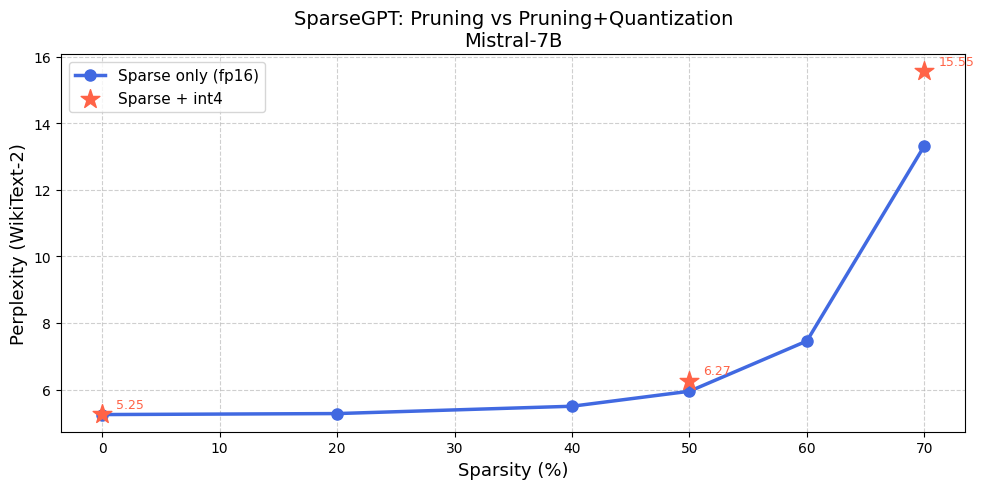

✅ Comparison plot saved!


In [5]:
import os
import matplotlib.pyplot as plt

log_dir = '/content/drive/MyDrive/sparsegpt_mistral'

# fp16 results
fp16_data = {0: 5.25, 20: 5.28, 40: 5.50, 50: 5.95, 60: 7.46, 70: 13.32}

# Parse quantized results
quant_data = {}
quant_logs = {
    0:  'log_dense_int4.txt',
    50: 'log_sparse50_int4.txt',
    70: 'log_sparse70_int4.txt',
}

for s, logfile in quant_logs.items():
    path = f'{log_dir}/{logfile}'
    if not os.path.exists(path):
        print(f"⚠️ Missing {logfile}")
        continue
    with open(path, 'r') as f:
        for line in f.readlines():
            if line.startswith('Perplexity:'):
                quant_data[s] = float(line.strip().split(': ')[1])
                print(f"✅ {logfile} → {quant_data[s]:.2f}")
                break

plt.figure(figsize=(10, 5))
plt.plot(list(fp16_data.keys()), list(fp16_data.values()),
         marker='o', linewidth=2.5, markersize=8,
         color='royalblue', label='Sparse only (fp16)')
if quant_data:
    plt.scatter(list(quant_data.keys()), list(quant_data.values()),
                marker='*', s=200, color='tomato', zorder=5, label='Sparse + int4')
    for x, y in quant_data.items():
        plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                    xytext=(10, 5), fontsize=9, color='tomato')
plt.xlabel('Sparsity (%)', fontsize=13)
plt.ylabel('Perplexity (WikiText-2)', fontsize=13)
plt.title('SparseGPT: Pruning vs Pruning+Quantization\nMistral-7B', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{log_dir}/pruning_vs_quantization.png', dpi=150)
plt.show()
print("✅ Comparison plot saved!")

# 6. Zero-Shot Evaluation for Mistral

6. Zero-Shot Evaluation for Mistral

In [7]:
# ⚠️ NOTE FOR REPRODUCIBILITY:
# After this cell finishes, you MUST:
# 1. Runtime → Restart Runtime
# 2. Re-run Cell 1
# 3. Then continue with Cell 7

import os, subprocess

# ── Upgrade transformers for Mistral tokenizer support ──
os.system('pip install -q transformers==4.40.0')  # ← newer version for Mistral
os.system('pip install -q lm-eval==0.4.2 peft==0.9.0')

import accelerate.utils.memory as mem
import torch, gc
if not hasattr(mem, 'clear_device_cache'):
    def clear_device_cache():
        gc.collect()
        torch.cuda.empty_cache()
    mem.clear_device_cache = clear_device_cache
try:
    import peft.utils.loftq_utils as loftq
    loftq.clear_device_cache = mem.clear_device_cache
except:
    pass
print("✅ peft + lm-eval + transformers 4.40 ready!\n")

log_dir = '/content/drive/MyDrive/sparsegpt_mistral'
tasks = "hellaswag,winogrande,piqa,arc_easy,arc_challenge"

# fp16 checkpoints
fp16_experiments = [
    {'checkpoint': f'{log_dir}/sparse{s}/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse{s}.json',
     'label': f'sparse{s}_fp16'}
    for s in [0, 20, 40, 50, 60, 70]
]

# Quantized checkpoints
quant_experiments = [
    {'checkpoint': f'{log_dir}/dense_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_dense_int4.json',
     'label': 'dense_int4'},
    {'checkpoint': f'{log_dir}/sparse50_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse50_int4.json',
     'label': 'sparse50_int4'},
    {'checkpoint': f'{log_dir}/sparse70_int4/checkpoints',
     'result_file': f'{log_dir}/zeroshot_sparse70_int4.json',
     'label': 'sparse70_int4'},
]

for exp in fp16_experiments + quant_experiments:
    checkpoint  = exp['checkpoint']
    result_file = exp['result_file']
    label       = exp['label']

    if not os.path.exists(checkpoint):
        print(f"⚠️ No checkpoint for {label} — skipping")
        continue
    if os.path.exists(result_file):
        print(f"⏭️ {label} already evaluated — skipping")
        continue

    print(f"\n{'='*50}")
    print(f"  🔄 Zero-shot eval: {label}")
    print(f"{'='*50}")

    cmd = ['python', '-m', 'lm_eval', '--model', 'hf',
           '--model_args', f'pretrained={checkpoint},tokenizer=mistralai/Mistral-7B-v0.1,dtype=float16',
           '--tasks', tasks, '--num_fewshot', '0',
           '--batch_size', '8', '--output_path', result_file,
           '--device', 'cuda']

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                               stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        print(line, end='')
    process.wait()

    if process.returncode != 0:
        print(f"❌ {label} FAILED!")
    elif os.path.exists(result_file):
        print(f"✅ {label} done!")
    else:
        print(f"❌ {label} — no output file!")

print("\n🎉 All zero-shot evaluations complete!")
print("\n⚠️ RESTART RUNTIME NOW before running Cell 7!")
print("   Runtime → Restart Runtime → Re-run Cell 1 → Continue from Cell 7")

✅ peft + lm-eval + transformers 4.40 ready!

⏭️ sparse0_fp16 already evaluated — skipping
⏭️ sparse20_fp16 already evaluated — skipping
⏭️ sparse40_fp16 already evaluated — skipping
⏭️ sparse50_fp16 already evaluated — skipping
⏭️ sparse60_fp16 already evaluated — skipping
⏭️ sparse70_fp16 already evaluated — skipping
⏭️ dense_int4 already evaluated — skipping
⏭️ sparse50_int4 already evaluated — skipping
⏭️ sparse70_int4 already evaluated — skipping

🎉 All zero-shot evaluations complete!

⚠️ RESTART RUNTIME NOW before running Cell 7!
   Runtime → Restart Runtime → Re-run Cell 1 → Continue from Cell 7


# 7. Zero-Shot Plot (fp16 vs int4)

7. Zero-Shot Plot (fp16 vs int4)

Mistral-7B Zero-Shot Average Accuracy
  Sparsity       fp16       int4
-----------------------------------
        0%  0.7410  0.7410
       20%  0.7385       -
       40%  0.7199       -
       50%  0.6938  0.6700
       60%  0.6228       -
       70%  0.4629  0.4375


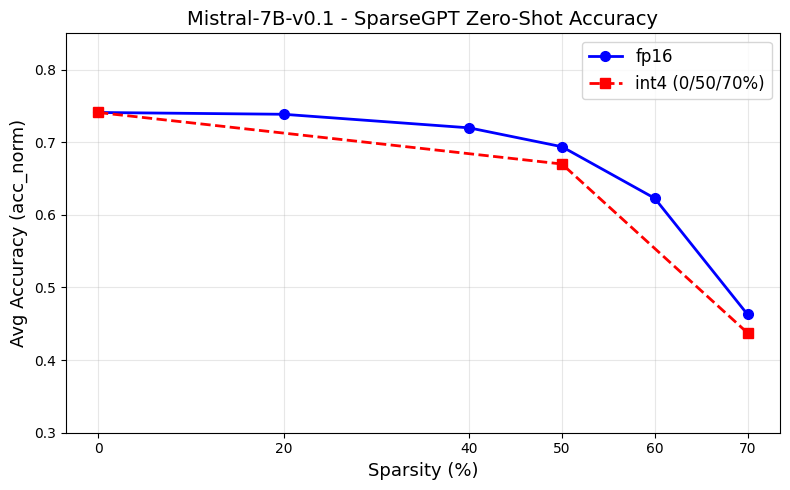

Plot saved to /content/drive/MyDrive/sparsegpt_mistral/mistral_zeroshot_plot.png


In [2]:
import json, os
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

RESULTS_DIR = '/content/drive/MyDrive/sparsegpt_mistral'
TASKS = ['winogrande', 'piqa', 'hellaswag', 'arc_easy', 'arc_challenge']

def load_results(fname):
    with open(os.path.join(RESULTS_DIR, fname)) as f:
        return json.load(f)

def avg_acc(results):
    accs = []
    for task in TASKS:
        r = results['results'][task]
        if 'acc_norm,none' in r:
            accs.append(r['acc_norm,none'])
        else:
            accs.append(r['acc,none'])
    return np.mean(accs)

sparsities_fp16 = [0, 20, 40, 50, 60, 70]
files_fp16 = [
    'zeroshot_sparse0.json',
    'zeroshot_sparse20.json',
    'zeroshot_sparse40.json',
    'zeroshot_sparse50.json',
    'zeroshot_sparse60.json',
    'zeroshot_sparse70.json',
]
accs_fp16 = [avg_acc(load_results(f)) for f in files_fp16]

files_int4 = {
    0:  'zeroshot_dense_int4.json',
    50: 'zeroshot_sparse50_int4.json',
    70: 'zeroshot_sparse70_int4.json',
}
accs_int4 = {s: avg_acc(load_results(f)) for s, f in files_int4.items()}

print("Mistral-7B Zero-Shot Average Accuracy")
print("{:>10} {:>10} {:>10}".format("Sparsity", "fp16", "int4"))
print("-" * 35)
for s, a in zip(sparsities_fp16, accs_fp16):
    int4_str = "{:.4f}".format(accs_int4[s]) if s in accs_int4 else "     -"
    print("{:>9}%  {:.4f}  {}".format(s, a, int4_str))

plt.figure(figsize=(8, 5))
plt.plot(sparsities_fp16, accs_fp16, 'b-o', label='fp16', linewidth=2, markersize=7)

int4_x = sorted(accs_int4.keys())
int4_y = [accs_int4[s] for s in int4_x]
plt.plot(int4_x, int4_y, 'r--s', label='int4 (0/50/70%)', linewidth=2, markersize=7)

plt.xlabel('Sparsity (%)', fontsize=13)
plt.ylabel('Avg Accuracy (acc_norm)', fontsize=13)
plt.title('Mistral-7B-v0.1 - SparseGPT Zero-Shot Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(sparsities_fp16)
plt.ylim(0.3, 0.85)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'mistral_zeroshot_plot.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print("Plot saved to " + plot_path)

# 8. Auto Disconnect

8. Auto Disconnect (AFK) for saving GPU Hours

In [ ]:
# Cell 8 — Auto Disconnect
from google.colab import runtime
import time

print("✅ All done! Results saved to Drive.")
print("💤 Disconnecting in 60 seconds...")
time.sleep(60)
runtime.unassign()